## 01. 군집화와 DBSCAN

### 01-01. 군집화 복습

군집화는 비슷한 데이터끼리 같은 그룹으로 묶는 방법이다.  
KMeans 교안에서 이미 다룬 것처럼, 군집화는 정답 class를 맞히는 작업이 아니라 데이터 안의 묶음 구조를 찾는 작업이다.

중요한 점은 군집 번호가 정답 class가 아니라는 것이다.  
예를 들어 모델이 데이터를 `cluster 0`, `cluster 1`로 나누더라도 이 번호는 모델이 붙인 임의의 이름표이다.  
`0번이 더 좋다`, `1번이 더 높은 등급이다` 같은 의미는 자동으로 생기지 않는다.

군집화 결과는 사람이 다시 해석해야 의미가 생긴다.  
고객 데이터라면 각 군집의 평균 구매 금액, 방문 횟수, 최근 구매일을 비교해 `VIP 고객`, `신규 고객`, `이탈 위험 고객`처럼 이름을 붙일 수 있다.

---

### 01-02. DBSCAN이란?

DBSCAN은 **Density-Based Spatial Clustering of Applications with Noise**의 약자이다.  
이름 그대로 **밀도 기반 군집화** 알고리즘이며, 데이터가 빽빽하게 모여 있는 영역을 하나의 군집으로 찾는다.

KMeans가 중심점과 거리를 기준으로 군집을 나누는 방식이라면, DBSCAN은 주변에 이웃 데이터가 충분히 많은지를 기준으로 군집을 확장한다.

DBSCAN의 핵심 특징은 다음과 같다.

- 군집 수를 미리 정하지 않아도 됨.
- 밀도가 이어지는 모양을 따라 군집을 만들 수 있음.
- 군집에 속하지 않는 점을 노이즈로 분리할 수 있음.
- scikit-learn에서는 노이즈를 label `-1`로 표시함.

한 줄로 정리하면 다음과 같다.

> DBSCAN은 데이터가 빽빽하게 모여 있는 영역을 군집으로 보고, 충분히 연결되지 않은 점은 노이즈로 분리하는 군집화 알고리즘이다.

---

### 01-03. 이미지로 보는 DBSCAN 개념


![](https://d.pr/i/Re9qoB+)

- DBSCAN은 모든 점을 같은 방식으로 단순히 나누지 않고, 밀도가 높은 영역을 중심으로 군집을 확장함.
- 데이터가 이어져 있는 모양이면 둥근 군집이 아니어도 하나의 군집으로 잡을 수 있음.
- 군집에서 멀리 떨어져 있거나 주변 이웃이 부족한 점은 노이즈로 분리될 수 있음.

![](https://d.pr/i/T3srVy+)

- KMeans처럼 중심점 하나를 기준으로 나누는 것이 아니라, 점 주변의 이웃 개수와 연결 관계를 봄.
- 밀도가 이어져 있으면 군집이 곡선형으로도 형성될 수 있음.
- 그래서 Moon 데이터처럼 휘어진 구조에서 KMeans보다 자연스러운 결과를 만들 수 있음.

---

### 01-04. DBSCAN은 어디에 쓰는가?

DBSCAN은 군집 수를 모르거나, 이상치를 함께 보고 싶은 상황에서 자주 사용한다.

- **지리 데이터 분석**: 사고 다발 지역, 상권 밀집 지역 탐지.
- **이상 감지**: 금융 거래, 센서 데이터에서 일반 패턴과 다른 점 탐지.
- **고객 행동 분석**: 비슷한 행동을 보이는 고객 그룹과 특이 행동 고객 탐색.
- **이미지/공간 데이터 분석**: 위치가 가까운 픽셀이나 객체를 묶는 사전 분석.

---

### 01-05. KMeans와 DBSCAN 비교

KMeans와 DBSCAN은 모두 군집화 알고리즘이지만 기준이 다르다.

- **KMeans**: 중심점과 거리 기준으로 데이터를 `k`개 군집으로 나눔.
- **DBSCAN**: 데이터가 빽빽하게 모인 밀도 영역을 따라 군집을 확장함.

따라서 KMeans는 둥글고 비슷한 크기의 군집에 이해하기 쉽고, DBSCAN은 곡선형 군집이나 노이즈가 있는 데이터에서 장점을 보일 수 있다.  
단, DBSCAN은 `eps`, `min_samples` 설정에 민감하므로 파라미터를 바꿔 보며 결과를 해석해야 한다.


## 02. DBSCAN 핵심 개념 정리

DBSCAN을 이해할 때는 `eps`, `min_samples`, core point, border point, noise point를 분리해서 봐야 한다.

![](https://d.pr/i/tiIr6K+)

- 점 하나를 기준으로 `eps` 반경 안에 주변 점이 얼마나 있는지 확인함.
- 주변 점이 충분히 많으면 **core point**, 핵심 포인트가 됨.
- 핵심 포인트 주변에 붙어 있지만 자신은 핵심 조건을 만족하지 못하면 **border point**, 경계 포인트가 됨.
- 어떤 핵심 포인트와도 충분히 연결되지 못하면 **noise point**, 노이즈 포인트가 됨.

---

### 02-01. eps(epsilon)

`eps`는 한 점 주변을 이웃으로 볼 거리 반경이다.  
`eps` 반경 안에 들어오는 점들을 이웃으로 계산한다.

- `eps`가 너무 작으면 이웃이 적어져 노이즈가 많아질 수 있음.
- `eps`가 너무 크면 서로 다른 군집이 하나로 합쳐질 수 있음.
- DBSCAN에서 가장 민감하게 결과를 바꾸는 값 중 하나임.

쉽게 말하면 `eps`는 “어디까지를 가까운 이웃으로 볼 것인가?”를 정하는 값이다.

---

### 02-02. min_samples

`min_samples`는 한 점이 핵심 포인트가 되기 위해 필요한 최소 이웃 수이다.  
scikit-learn의 DBSCAN에서는 자기 자신도 이 개수에 포함된다.

- 값이 작으면 비교적 느슨하게 군집을 인정함.
- 값이 크면 더 빽빽한 영역만 군집으로 인정함.
- 노이즈를 얼마나 엄격하게 분리할지에 영향을 줌.

쉽게 말하면 `min_samples`는 “이 정도 인원이 모여야 군집이라고 인정하겠다”는 기준이다.

---

### 02-03. core point, 핵심 포인트

핵심 포인트는 `eps` 반경 안에 `min_samples` 이상 샘플이 있는 점이다.  
군집을 확장하는 중심 역할을 한다.

> 주변에 친구가 충분히 많은 점은 군집을 만들 수 있는 중심 후보이다.

---

### 02-04. border point, 경계 포인트

경계 포인트는 자기 주변에는 이웃이 충분하지 않지만, 핵심 포인트의 `eps` 반경 안에 있어서 군집에 포함되는 점이다.


> 스스로 군집을 만들 정도로 주변이 빽빽하지는 않지만, 이미 만들어진 군집 옆에 붙어 있는 점이다.

---

### 02-05. noise point, 노이즈 포인트

노이즈 포인트는 어떤 핵심 포인트와도 충분히 연결되지 않은 점이다.  
scikit-learn의 DBSCAN 결과에서는 label `-1`로 표시된다.

주의할 점은 `-1`이 나쁜 데이터라는 뜻은 아니라는 것이다.  
현재 `eps`, `min_samples` 기준에서 어떤 군집에도 자연스럽게 포함되지 않았다는 의미이다.

---

### 02-06. DBSCAN 알고리즘 흐름

1. 아직 방문하지 않은 점을 하나 선택함.
2. 그 점의 `eps` 반경 안에 이웃이 몇 개 있는지 확인함.
3. 이웃 수가 `min_samples` 이상이면 핵심 포인트로 보고 군집을 시작함.
4. 연결된 핵심 포인트와 경계 포인트를 계속 확장해 같은 군집으로 묶음.
5. 충분히 연결되지 않은 점은 노이즈 `-1`로 남김.

한 줄로 정리하면 다음과 같다.

> DBSCAN은 핵심 포인트를 시작점으로 밀도가 이어지는 영역을 따라 군집을 확장하고, 연결되지 않는 점은 노이즈로 분리한다.

---

### 02-07. eps와 min_samples를 고르는 기준

DBSCAN은 KMeans처럼 `k`를 직접 정하지 않는다.  
대신 `eps`와 `min_samples`가 군집 수와 노이즈 수를 결정한다.

먼저 `min_samples`는 보통 데이터 차원과 노이즈 허용 정도를 보고 정한다.

- 2차원 예제 데이터: `min_samples=4` 또는 `5`부터 시도할 수 있음.
- 노이즈를 더 엄격하게 분리하고 싶으면 값을 키움.
- 너무 크게 잡으면 정상 데이터도 노이즈로 빠질 수 있음.

그다음 `eps`는 여러 후보를 비교하며 고른다.

- `eps`가 너무 작음: 군집이 잘게 쪼개지고 `-1` 노이즈가 많아짐.
- `eps`가 적절함: 자연스러운 군집 수가 나오고 노이즈가 과하지 않음.
- `eps`가 너무 큼: 서로 다른 군집이 하나로 합쳐짐.

실무에서는 다음을 함께 본다.

1. 군집 수가 너무 많거나 너무 적지 않은가
2. 노이즈 수가 과도하지 않은가
3. 그래프에서 군집 모양이 자연스러운가
4. 군집별 특성이 사람이 해석 가능한가
5. 필요하면 노이즈를 이상치 후보로 따로 분석할 수 있는가

즉, DBSCAN에서는 “최적 k”를 찾는 대신 “밀도 기준이 데이터 구조를 자연스럽게 설명하는가”를 판단한다.


## 03. 실습 환경 준비

Moon 데이터로 곡선형 군집을 만들고, KMeans와 DBSCAN 결과를 비교함. 이후 Iris 데이터에 DBSCAN을 적용해 실제 target과 군집 결과를 해석함.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.vq import kmeans
from sklearn import cluster

from sklearn.datasets import make_moons, load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score


## 04. Moon 데이터 생성

Moon 데이터는 두 개의 반달 모양 군집으로 구성된 예제 데이터임. KMeans처럼 중심점 기준으로 나누는 알고리즘은 이런 곡선형 구조를 잘 나누기 어려울 수 있음.


,feature_1,feature_2,true_group
0,0.695082,-0.339824,1
1,2.068335,-0.130677,1
2,-0.153816,0.454045,1
3,0.876118,0.296114,0
4,1.182878,-0.499083,1


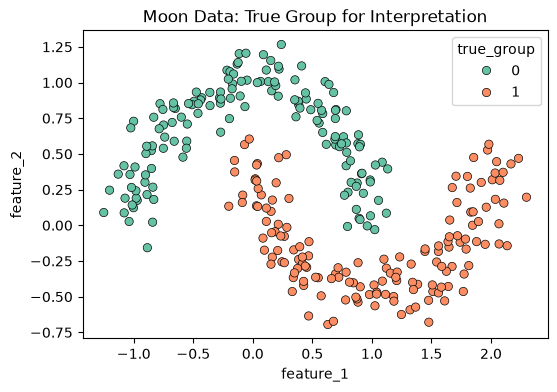

In [2]:
moon_X, moon_y = make_moons(n_samples=300, noise=0.11, random_state=42)

moon_df = pd.DataFrame(moon_X, columns=['feature_1', 'feature_2'])
moon_df['true_group'] = moon_y

display(moon_df.head())

plt.figure(figsize=(6, 4))
sns.scatterplot(data=moon_df, x='feature_1', y='feature_2', hue='true_group', palette='Set2', edgecolor='black')
plt.title('Moon Data: True Group for Interpretation')
plt.show()


## 05. Moon 데이터 스케일링

DBSCAN과 KMeans 모두 거리 기반 알고리즘임. feature 범위가 크게 다르면 거리 계산이 왜곡될 수 있으므로 스케일링을 적용함.


In [4]:
scaler = StandardScaler()

moon_X_scaled = scaler.fit_transform(moon_X)

moon_scaled_df = pd.DataFrame(
    moon_X_scaled,
    columns=['feature_1_scaled', 'feature_2_scaled']
)

## 06. KMeans와 DBSCAN 비교

KMeans는 중심점 기준으로 가장 가까운 군집을 고름. DBSCAN은 밀도가 이어지는 영역을 따라 군집을 확장함. Moon 데이터에서는 이 차이가 눈에 잘 보임.


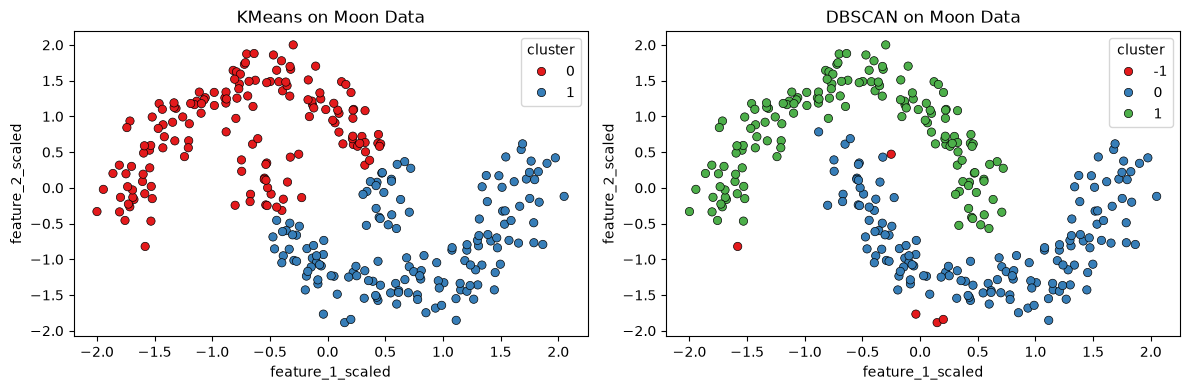

In [9]:
kmeans_moon = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10,
)

moon_kmeans_labels = kmeans_moon.fit_predict(moon_X_scaled)

# DBSCAN : eps 반경 내에 min_samples 이상의 이웃 데이터가 있으면 같은 밀도 영역으로 봄
dbscan_moon = DBSCAN(
    eps=0.3,
    min_samples=5,
)

moon_dbscan_labels = dbscan_moon.fit_predict(moon_X_scaled)

moon_compare_df = moon_scaled_df.copy()
moon_compare_df['kmeans_cluster'] = moon_kmeans_labels
moon_compare_df['dbscan_cluster'] = moon_dbscan_labels

# 시각화
fig, axes = plt.subplots(1,2,figsize=(12,4))

sns.scatterplot(
    data=moon_compare_df,
    x='feature_1_scaled',
    y='feature_2_scaled',
    hue='kmeans_cluster',
    palette='Set1',
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title('KMeans on Moon Data')
axes[0].legend(title='cluster')

sns.scatterplot(
    data=moon_compare_df,
    x='feature_1_scaled',
    y='feature_2_scaled',
    hue='dbscan_cluster',
    palette='Set1',
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title('DBSCAN on Moon Data')
axes[1].legend(title='cluster')

plt.tight_layout()
plt.show()

# KMeans는 중심점 기준으로 군집을 형성하기 때문에
# 반달 모양 데이터에 적합하지 않다

# DBSCAN은 밀도가 이어지는 영역을 따라 군집을 자동적으로 형성하기 때문에
# 반달, 원형 같은 곡선형 데이터에 적합하다
# -1 == Noise Point

## 07. DBSCAN 파라미터 변화 확인

DBSCAN은 `eps`와 `min_samples`에 민감하다.  
같은 데이터라도 설정이 달라지면 군집 수와 노이즈 수가 크게 바뀔 수 있다.

이 셀에서는 여러 후보를 비교하면서 다음을 확인한다.

- `cluster_count`: 노이즈 `-1`을 제외한 실제 군집 개수
- `noise_count`: 어떤 군집에도 속하지 못한 노이즈 샘플 개수
- 산점도: 군집이 데이터 모양을 자연스럽게 따라가는지

해석 기준은 다음과 같다.

- 노이즈가 너무 많으면 `eps`가 너무 작거나 `min_samples`가 너무 클 수 있음.
- 군집이 하나로 합쳐지면 `eps`가 너무 클 수 있음.
- 군집이 지나치게 잘게 쪼개지면 `eps`가 너무 작을 수 있음.
- 군집 수만 보지 말고 그래프에서 밀도 구조가 자연스러운지 함께 봐야 함.

KMeans의 `k` 선택처럼 숫자 하나만 고르는 문제가 아니라, DBSCAN은 `eps`, `min_samples`, 노이즈 수, 그래프 모양을 함께 보며 결정한다.


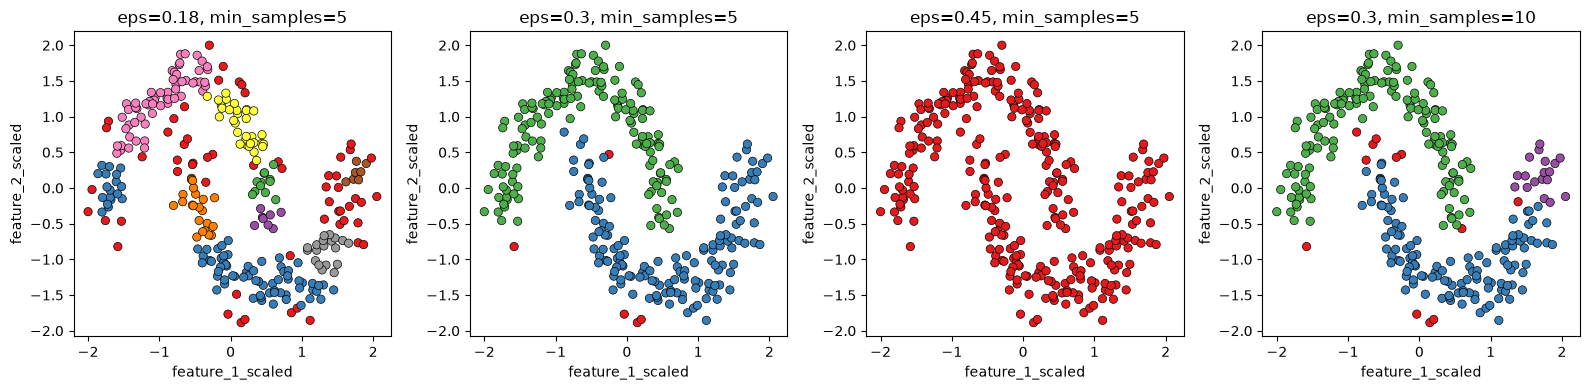

,eps,min_samples,cluster_count,noise_count
0,0.18,5,10,53
1,0.30,5,2,5
2,0.45,5,1,0
3,0.30,10,3,12


In [11]:
# eps, min_samples의 변화에 따라 DBSCAN 결과가 어떻게 달라지는지 비교
param_results = []
param_candidates = [
    {'eps':0.18, 'min_samples':5},
    {'eps':0.30, 'min_samples':5},
    {'eps':0.45, 'min_samples':5},
    {'eps':0.30, 'min_samples':10},
]

fig, axes = plt.subplots(1,4,figsize=(16,4))

for ax, params in zip(axes, param_candidates):
    model = DBSCAN(
        eps=params['eps'],
        min_samples=params['min_samples'],
    )

    labels = model.fit_predict(moon_X_scaled) # 학습 + 군집 예측

    # 군집 개수
    cluster_count = len(set(labels) - {-1})

    # 노이즈의 개수
    noise_count = np.sum(labels == -1)

    param_results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'cluster_count': cluster_count,
        'noise_count': noise_count,
    })

    plot_df = moon_scaled_df.copy()
    plot_df['cluster'] = labels
    sns.scatterplot(
        data=plot_df,
        x='feature_1_scaled',
        y='feature_2_scaled',
        hue='cluster',
        palette='Set1',
        edgecolor='black',
        legend=False,
        ax=ax
    )

    ax.set_title(f'eps={params["eps"]}, min_samples={params["min_samples"]}')

plt.tight_layout()
plt.show()
display(pd.DataFrame(param_results))

## 08. Iris 데이터에 DBSCAN 적용

Iris 데이터는 실제 target이 있지만, DBSCAN 학습에는 target을 사용하지 않음. target은 군집 결과가 실제 품종과 어떻게 대응되는지 해석할 때만 사용함.


In [12]:
iris = load_iris(as_frame=True)
iris_X = iris.data.copy()
iris_y = iris.target.copy()
target_names = dict(enumerate(iris.target_names))

iris_scaler = StandardScaler()
iris_X_scaled = iris_scaler.fit_transform(iris_X)

iris_dbscan = DBSCAN(eps=0.8, min_samples=5)
iris_labels = iris_dbscan.fit_predict(iris_X_scaled)

iris_result_df = iris_X.copy()
iris_result_df['target'] = iris_y
iris_result_df['target_name'] = iris_result_df['target'].map(target_names)
iris_result_df['cluster'] = iris_labels

display(iris_result_df.head())
display(pd.Series(iris_labels).value_counts().sort_index().rename('count').to_frame())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,cluster
0,5.1,3.5,1.4,0.2,0,setosa,0
1,4.9,3.0,1.4,0.2,0,setosa,0
2,4.7,3.2,1.3,0.2,0,setosa,0
3,4.6,3.1,1.5,0.2,0,setosa,0
4,5.0,3.6,1.4,0.2,0,setosa,0


,count
-1,4
0,49
1,97


## 09. 실제 품종과 DBSCAN 군집 비교

실제 target이 있는 데이터에서는 군집 결과와 실제 class를 교차표로 비교할 수 있음. 단, 군집 번호는 class 번호와 같은 의미가 아님.


In [13]:
cluster_target_table = pd.crosstab(
    iris_result_df['target_name'],
    iris_result_df['cluster'],
    rownames=['actual_class'],
    colnames=['dbscan_cluster']
)

display(cluster_target_table)

# 노이즈가 아닌 군집이 2개 이상일 때만 silhouette_score를 참고용으로 계산함.
non_noise_mask = iris_result_df['cluster'] != -1
non_noise_labels = iris_result_df.loc[non_noise_mask, 'cluster']

if non_noise_labels.nunique() >= 2:
    score = silhouette_score(iris_X_scaled[non_noise_mask], non_noise_labels)
    print(f'노이즈 제외 silhouette_score: {score:.4f}')
else:
    print('노이즈를 제외한 군집 수가 2개 미만이라 silhouette_score를 계산하지 않음.')

dbscan_cluster,-1,0,1
actual_class,,,
setosa,1,49,0
versicolor,0,0,50
virginica,3,0,47


노이즈 제외 silhouette_score: 0.5979


## 10. PCA 2차원 시각화로 DBSCAN 결과 보기

Iris는 feature가 4개라 군집 결과를 바로 2차원에서 보기 어렵음. PCA로 2차원 좌표를 만든 뒤 실제 품종과 DBSCAN 군집을 나란히 비교함.


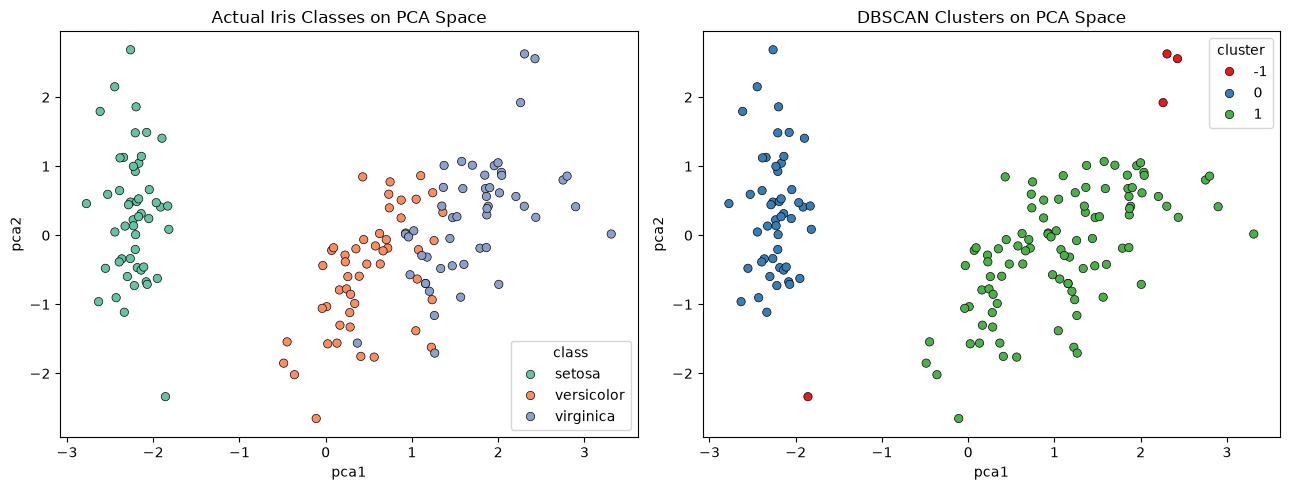

In [14]:
iris_pca = PCA(n_components=2)
iris_X_pca = iris_pca.fit_transform(iris_X_scaled)

iris_result_df['pca1'] = iris_X_pca[:, 0]
iris_result_df['pca2'] = iris_X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=iris_result_df, x='pca1', y='pca2', hue='target_name', palette='Set2', edgecolor='black', ax=axes[0])
axes[0].set_title('Actual Iris Classes on PCA Space')
axes[0].legend(title='class')

sns.scatterplot(data=iris_result_df, x='pca1', y='pca2', hue='cluster', palette='Set1', edgecolor='black', ax=axes[1])
axes[1].set_title('DBSCAN Clusters on PCA Space')
axes[1].legend(title='cluster')

plt.tight_layout()
plt.show()

## 11. 수업 마무리 정리

- DBSCAN은 밀도 기반 군집화 알고리즘이며 군집 수를 미리 정하지 않음.
- `eps`는 이웃으로 볼 거리 반경, `min_samples`는 핵심 포인트가 되기 위한 최소 이웃 수임.
- label `-1`은 노이즈 또는 이상치 후보를 의미함.
- KMeans는 중심점 기준, DBSCAN은 밀도 기준이라는 차이를 Moon 데이터에서 확인함.
- DBSCAN은 파라미터에 민감하므로 그래프, 군집 수, 노이즈 수를 함께 확인해야 함.
- `eps`가 작으면 노이즈가 늘거나 군집이 쪼개질 수 있고, `eps`가 크면 군집이 합쳐질 수 있음.
- DBSCAN에서는 “최적 k”보다 “현재 밀도 기준이 데이터 구조와 해석 목적에 맞는가”를 판단하는 것이 중요함.
